# Music fingerprinting with Chromaprint

## Music track identification with AcoustID

[Chromaprint](https://oxygene.sk/2011/01/how-does-chromaprint-work/) is an acoustic fingerprinting algorithm based on [chroma features](https://en.wikipedia.org/wiki/Chroma_feature). [AcoustID](https://en.wikipedia.org/wiki/AcoustID) is a web service that relies on chromaprints to identify tracks from the MusicBrainz database.

Queries to AcousticID require a **client** key, the song **duration**, and the **fingerprint**. Besides, a query can ask for additional metadata from the MusicBrainz database using the field **meta** (https://acoustid.org/webservice).

Essentia provides a wrapper algorithm, [Chromaprinter]((http://essentia.upf.edu/documentation/reference/std_Chromaprinter.html)), for computing fingerprints with the Chromaprint library.  In standard mode, a fingerprint is computed for the entire audio duration. It can then be used to generate a query as in the example below:

In [4]:
# the specified file is not provided with this notebook, try using your own music instead
audio = es.MonoLoader(filename='Desakato-Tiempo de cobardes.mp3', sampleRate=44100)()
fingerprint = es.Chromaprinter()(audio)

client = 'hGU_Gmo7vAY' # This is not a valid key. Use your key.
duration = len(audio) / 44100.

# Composing a query asking for the fields: recordings, releasegroups and compress.
query = 'http://api.acoustid.org/v2/lookup?client=%s&meta=recordings+releasegroups+compress&duration=%i&fingerprint=%s' \
%(client, duration, fingerprint)

from six.moves import urllib
page = urllib.request.urlopen(query)
print(page.read())

{"status": "ok", "results": [{"recordings": [{"artists": [{"id": "b02d0e59-b9c2-4009-9ebd-bfac7ffa0ca3", "name": "Desakato"}], "duration": 129, "releasegroups": [{"type": "Album", "id": "a38dc1ea-74fc-44c2-a31c-783810ba1568", "title": "La Teor\u00eda del Fuego"}], "title": "Tiempo de cobardes", "id": "9b91e561-a9bf-415a-957b-33e6130aba76"}], "score": 0.937038, "id": "23495e47-d670-4e86-bd08-b1b24a84f7c7"}]}


Chromaprints can also be computed in real-time using streaming mode of the algorithm. In this case, a fingerprint is computed each `analysisTime` seconds.

For the use-case shown in the previous example, the fingerprint can be internally stored until the end of the signal using the `concatenate` flag (True by default). In this case, only one chromaprint is returned after the end of the audio stream.

In [9]:
loader = ess.MonoLoader(filename = 'Music/Desakato-La_Teoria_del_Fuego/01. Desakato-Tiempo de cobardes.mp3')
fps = ess.Chromaprinter(analysisTime=20, concatenate=True)
pool = ess.essentia.Pool()

# Conecting the algorithms
loader.audio >> fps.signal
fps.fingerprint >> (pool, 'chromaprint')

ess.essentia.run(loader)

fp = pool['chromaprint'][0]

To make fingerprints more convenient, they are compressed as char arrays. We can use the `decode_fingerprint` functionality in the [pyacoustid](https://pypi.org/project/pyacoustid/) package to get a numerical representation of the chromaprint and visualize it.

Text(0.5,1,u'Binary representation of a Chromaprint ')

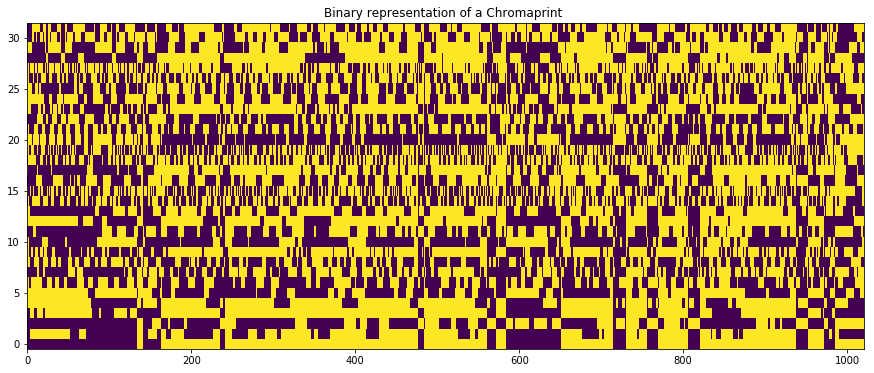

In [71]:
import acoustid as ai

fp_int = ai.chromaprint.decode_fingerprint(fp)[0]

fb_bin = [list('{:032b}'.format(abs(x))) for x  in fp_int] # Int to unsigned 32-bit array

arr = np.zeros([len(fb_bin), len(fb_bin[0])])

for i in range(arr.shape[0]):
    arr[i,0] = int(fp_int[i] > 0) # The sign is added to the first bit
    for j in range(1, arr.shape[1]):
        arr[i,j] = float(fb_bin[i][j])
        
plt.imshow(arr.T, aspect='auto', origin='lower')
plt.title('Binary representation of a Chromaprint ')

## Query audio segment identification within an audio track

Chromaprints also allow identifying and locating a query music audio segment in a recording. This can be useful in various applications, for instance, song identification in radio/DJ streams.

In this example, we will use a short musical phrase from a Mozart recording (marked by red lines in the audio plot below), low-pass filtered for audio degradation, as a query. We will locate this query within the entire original recording.

The code is an adaptation of [this gist](https://gist.github.com/lalinsky/1099996) by Lukáš Lalinský.

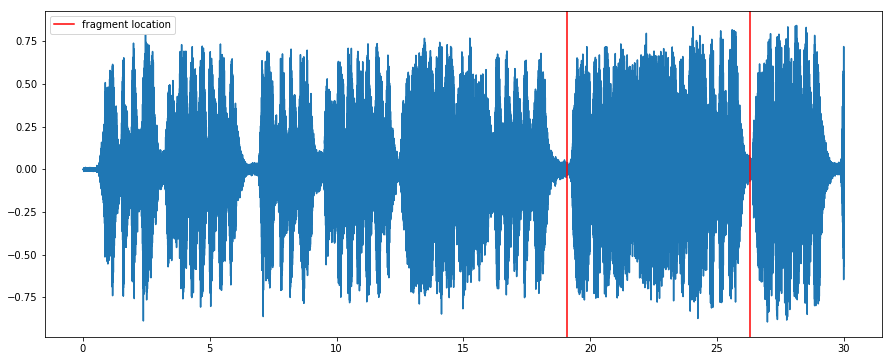

In [177]:
from pylab import plot, show, figure, imshow
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['figure.figsize'] = (15, 6) # set plot sizes to something larger than default

fs=44100
audio = es.MonoLoader(filename='../../../test/audio/recorded/mozart_c_major_30sec.wav', sampleRate=fs)() # this song is not available
time = np.linspace(0, len(audio)/float(fs), len(audio))

plot(time, audio)

# Segment limits
start = 19.1
end = 26.3

plt.axvline(x=start, color='red', label='fragment location')
plt.axvline(x=end, color='red')
plt.legend()

This is how the track sounds like:

In [105]:
IPython.display.Audio(audio, rate=44100)

To demonstrate the robustness of the fingerprinting algorithm, we will apply a 1st order lowpass filter at 16kHz to the musical phrase segment we want to identify. This kind of filtering resembles changes to frequency bandwidth that happen when encoding full-range lossless audio to a low-bitrate MP3. We expect the fingerprinting algorithm to be robust to such alterations.

In [176]:
fragment = audio[int(start*fs):int(end*fs)]
fragment = es.LowPass(cutoffFrequency=16000)(fragment)

IPython.display.Audio(fragment, rate=44100)

The first step is to compute and decode the chromaprints of the entire track and the modified segment.

In [168]:
import acoustid as ai
fp_full_char = es.Chromaprinter()(audio)
fp_frag_char = es.Chromaprinter()(fragment)

fp_full = ai.chromaprint.decode_fingerprint(fp_full_char)[0]
fp_frag = ai.chromaprint.decode_fingerprint(fp_frag_char)[0]

The identification process starts by finding common items (or frames) of the chromaprints. At this stage, only the 20 most significant bits are used.

In [169]:
full_20bit = [x & (1<<20 - 1) for x in fp_full]
short_20bit = [x & (1<<20 - 1) for x in fp_frag]

common = set(full_20bit) & set(short_20bit)

A reversed dictionary is created for convenience to access the timestamps given the 20-bit values.

In [171]:
def invert(arr):
    """
    Make a dictionary that with the array elements as keys and
    their positions positions as values.
    """
    map = {}
    for i, a in enumerate(arr):
        map.setdefault(a, []).append(i)
    return map

i_full_20bit = invert(full_20bit)
i_short_20bit = invert(short_20bit)

Now the offsets among the common items are stored:

In [172]:

duration = len(audio) / 44100.offsets = {}
for a in common:
    for i in i_full_20bit[a]:
        for j in i_short_20bit[a]:
            o = i - j
            offsets[o] = offsets.get(o, 0) + 1

All the detected offsets are filtered and scored. The criterion for filtering is the greatest number of common events. In this example, only the top 20 offsets are considered. The final score is computed by measuring the bitwise distance of the 32-bit vectors given the proposed offsets.

In [173]:
popcnt_table_8bit = [
    0,1,1,2,1,2,2,3,1,2,2,3,2,3,3,4,1,2,2,3,2,3,3,4,2,3,3,4,3,4,4,5,
    1,2,2,3,2,3,3,4,2,3,3,4,3,4,4,5,2,3,3,4,3,4,4,5,3,4,4,5,4,5,5,6,
    1,2,2,3,2,3,3,4,2,3,3,4,3,4,4,5,2,3,3,4,3,4,4,5,3,4,4,5,4,5,5,6,
    2,3,3,4,3,4,4,5,3,4,4,5,4,5,5,6,3,4,4,5,4,5,5,6,4,5,5,6,5,6,6,7,
    1,2,2,3,2,3,3,4,2,3,3,4,3,4,4,5,2,3,3,4,3,4,4,5,3,4,4,5,4,5,5,6,
    2,3,3,4,3,4,4,5,3,4,4,5,4,5,5,6,3,4,4,5,4,5,5,6,4,5,5,6,5,6,6,7,
    2,3,3,4,3,4,4,5,3,4,4,5,4,5,5,6,3,4,4,5,4,5,5,6,4,5,5,6,5,6,6,7,
    3,4,4,5,4,5,5,6,4,5,5,6,5,6,6,7,4,5,5,6,5,6,6,7,5,6,6,7,6,7,7,8,
]

def popcnt(x):
    """
    Count the number of set bits in the given 32-bit integer.
    """
    return (popcnt_table_8bit[(x >>  0) & 0xFF] +
            popcnt_table_8bit[(x >>  8) & 0xFF] +
            popcnt_table_8bit[(x >> 16) & 0xFF] +
            popcnt_table_8bit[(x >> 24) & 0xFF])


def ber(offset):
    """
    Compare the short snippet against the full track at given offset.
    """
    errors = 0
    count = 0
    for a, b in zip(fp_full[offset:], fp_frag):
        errors += popcnt(a ^ b)
        count += 1
    return max(0.0, 1.0 - 2.0 * errors / (32.0 * count))

matches = []
for count, offset in sorted([(v, k) for k, v in offsets.items()], reverse=True)[:20]:
    matches.append((ber(offset), offset))
matches.sort(reverse=True)

The offset with the best score is considered the optimal location of the segment.

position 0:19 with score 0.937500


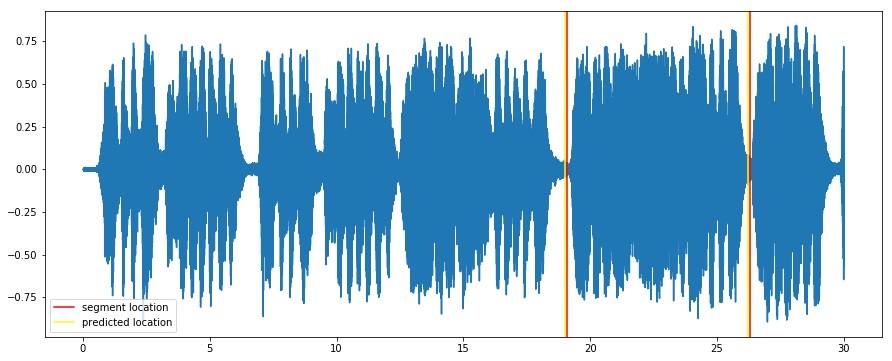

In [178]:
score, offset = matches[0]

offset_secs =int(offset * 0.1238) # each fingerprint item represents 0.1238 seconds

fp_duration = len(fp_frag) * 0.1238 + 2.6476 # there is also a duration offset found empirically

print "position %d:%02d with score %f" % (offset_secs / 60, offset_secs % 60, score)

plot(time, audio)

plt.axvline(x=start, color='red', label= 'segment location')
plt.axvline(x=end, color='red')

plt.axvline(x=offset_secs, color='yellow', label='predicted location')
plt.axvline(x=offset_secs + fp_duration, color='yellow')
plt.legend()